## Introduction to Econometrics
Prof. Roberto Renò - ESSEC Business School 

Based on:
**[gabors-data-analysis.com ](https://gabors-data-analysis.com/)**

 License: Free to share, modify and use for educational purposes. 
 Not to be used for commercial purposes.

## Class 2

## Risk management

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
from mizani.formatters import percent_format
from plotnine import *
from datetime import datetime
from scipy.stats import norm

warnings.filterwarnings("ignore")

# Current script folder
current_path = os.getcwd()
dirname = current_path.split("da_case_studies")[0]

# location folders (double check you have this on your pc)
data_in = dirname + "/Data/"
data_out = dirname + "/Data/"
output = dirname + "/output/"
func = dirname + "/Settings/"
sys.path.append(func)

# Import the prewritten helper functions
from py_helper_functions import *

In [ ]:
!pip install yfinance

In [2]:
# let's load data using an API from Yahoo Finance. You maybe need to install it pip install yfinance
import yfinance as yf

# Define the ticker symbol for S&P 500 (SPY ETF)
ticker_symbol = "^GSPC"

# Define start and end dates for the data
start_date = "2001-01-01"
end_date = pd.to_datetime("today").strftime("%Y-%m-%d")  # Current date

# Download S&P 500 data from Yahoo Finance
sp500_data = yf.download(ticker_symbol, start=start_date, end=end_date)

# Reset the index to move the date index to a column
sp500_data.reset_index(inplace=True)

# Extract Date and Close price columns from the downloaded data
sp500_prices = sp500_data[["Date", "Open", "Close"]]

# Print the first few rows of the downloaded data
print(sp500_prices.head())

# Save the data to a CSV file (optional)
sp500_prices.to_csv("sp500_daily_prices.csv", index=False)

# If you want to store the data in a DataFrame for further analysis
sp500 = pd.DataFrame(sp500_prices)

sp500 = sp500.dropna().reset_index(drop=True)

# Print the first few rows of the DataFrame
#print(sp500_df.head())

sp500.reset_index(drop=True).to_csv("output/sp500.csv")

[*********************100%***********************]  1 of 1 completed

Price        Date         Open        Close
Ticker                   ^GSPC        ^GSPC
0      2001-01-02  1320.280029  1283.270020
1      2001-01-03  1283.270020  1347.560059
2      2001-01-04  1347.560059  1333.339966
3      2001-01-05  1333.339966  1298.349976
4      2001-01-08  1298.349976  1295.859985


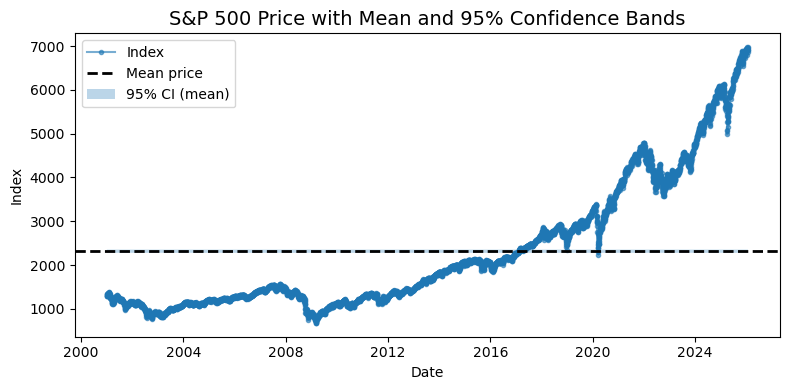

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sp500['Date'] = pd.to_datetime(sp500['Date'])

# Make Close strictly 1-D numeric
close = sp500['Close']
if isinstance(close, pd.DataFrame):          # happens with MultiIndex columns
    close = close.iloc[:, 0]
close = pd.to_numeric(close, errors='coerce')

df = pd.DataFrame({'Date': sp500['Date'], 'Close': close}).dropna()

price = df['Close'].to_numpy()
dates = df['Date'].to_numpy()

mean_price = float(np.mean(price))
std_price  = float(np.std(price, ddof=1))
n = price.size
ci = 1.96 * std_price / np.sqrt(n)

plt.figure(figsize=(8, 4))
plt.plot(dates, price, marker='.', linestyle='-', label='Index', alpha=0.6)

plt.axhline(y=mean_price, color='black', linestyle='--', linewidth=2, label='Mean price')

plt.fill_between(dates, mean_price - ci, mean_price + ci, alpha=0.3, label='95% CI (mean)')

plt.title('S&P 500 Price with Mean and 95% Confidence Bands', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Index')
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
# CREATE PERCENT RETURN
sp500["pct_return"] = (
    (sp500["Close"] - sp500.set_index("Date").shift(1).reset_index(drop=True)["Close"])
    / sp500.set_index("Date").shift(1).reset_index(drop=True)["Close"]
    * 100
)

Text(0.5, 1.0, 'Daily S&P500 Returns')

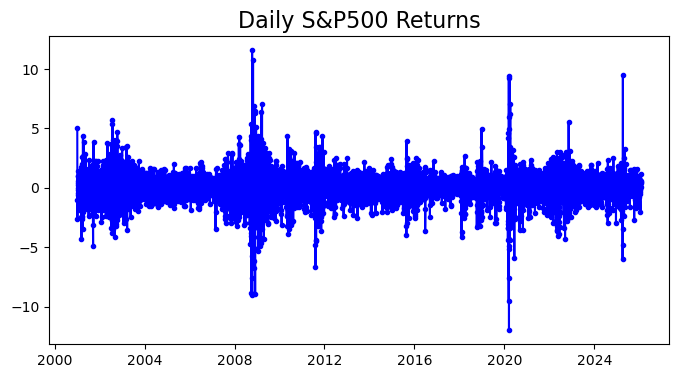

In [11]:
plt.figure(figsize=(8, 4))  
plt.plot(dates, sp500['pct_return'], marker='.', linestyle='-', color='b', label='Index')
plt.title('Daily S&P500 Returns', fontsize=16)

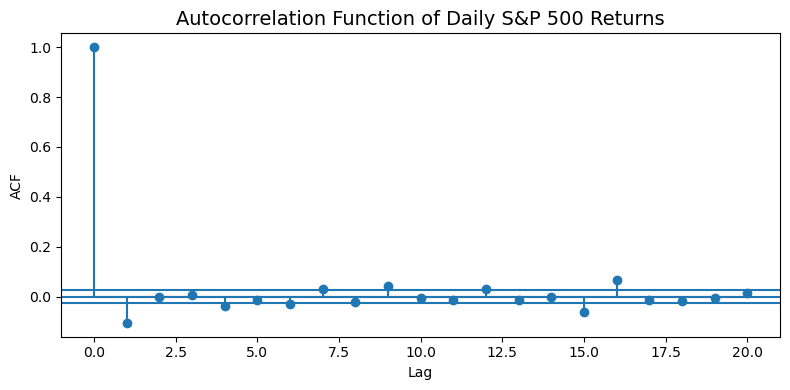

In [12]:
from statsmodels.tsa.stattools import acf

# Drop NaNs just in case
r = sp500['pct_return'].dropna().values

# Compute ACF (say up to 20 lags)
nlags = 20
acf_vals = acf(r, nlags=nlags, fft=True)

# 95% confidence bands
conf = 1.96 / np.sqrt(len(r))

plt.figure(figsize=(8, 4))
plt.stem(range(nlags + 1), acf_vals, use_line_collection=True)
plt.axhline(conf)
plt.axhline(-conf)
plt.axhline(0)

plt.title('Autocorrelation Function of Daily S&P 500 Returns', fontsize=14)
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.tight_layout()
plt.show()


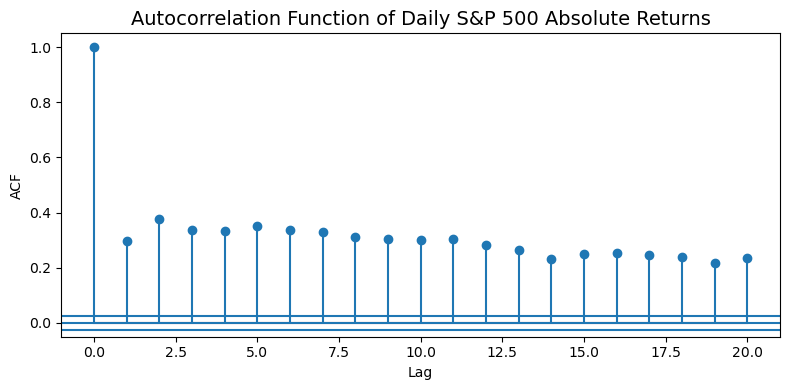

In [13]:
from statsmodels.tsa.stattools import acf

# Drop NaNs just in case
r = sp500['pct_return'].dropna().values

# Compute ACF (say up to 20 lags)
nlags = 20
acf_vals = acf(abs(r), nlags=nlags, fft=True)

# 95% confidence bands
conf = 1.96 / np.sqrt(len(r))

plt.figure(figsize=(8, 4))
plt.stem(range(nlags + 1), acf_vals, use_line_collection=True)
plt.axhline(conf)
plt.axhline(-conf)
plt.axhline(0)

plt.title('Autocorrelation Function of Daily S&P 500 Absolute Returns', fontsize=14)
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.tight_layout()
plt.show()


In [ ]:
sp500["DATE"] = pd.to_datetime(sp500["Date"], format="%Y-%m-%d")
sp500["year"] = sp500["DATE"].apply(lambda x: x.year)
sp500["month"] = sp500["DATE"].apply(lambda x: x.month)
sp500["yearmonth"] = sp500["year"] * 100 + sp500["month"]

In [ ]:
ggplot(sp500, aes("pct_return")) + geom_histogram(
    binwidth=0.25, color="white", fill="red", boundary=0, closed="left"
) + geom_vline(xintercept=-5, size=0.7, color="blue") + labs(
    x="Daily return (percent)", y="Frequency"
) + coord_cartesian(
    xlim=[-10, 10], ylim=[0, 900]
) + scale_y_continuous(
    expand=[0, 0]
) + geom_segment(
    aes(x=-6, y=220, xend=-5, yend=220)
) + annotate(
    "text", x=-8, y=220, label="5% loss", size=12
) + theme_bw()

In [ ]:
print(np.kurtosis(sp500['pct_return']))

In [ ]:
# a better view
(ggplot(sp500, aes(x='pct_return')) +
 geom_histogram(binwidth=0.25, color='white', fill='red', boundary=0) +
 geom_vline(xintercept=-5, size=0.7, color='blue') +
 labs(x='Daily return (percent)', y='Frequency') +
 coord_cartesian(xlim=(-10, 10)) +
 scale_y_log10() +  # Set log scale on y-axis
 scale_x_continuous(limits=(-10, 10)) +
 geom_segment(aes(x=-6, y=220, xend=-5, yend=220)) +
 annotate('text', x=-8, y=220, label='5% loss', size=12) +
 theme_bw())

In [ ]:
pct_return = sp500.pct_return.dropna()

A mental experiment. What is the data we downloaded is the **population** and we have to estimate the population mean using a sample?

The statistics of interest: the percentage of daily return which are less than -5%.

In [ ]:
#the population mean
pmean = sum(sp500.pct_return < -5) / len(sp500.pct_return) * 100
print('Population mean: ',pmean,' %')

In [ ]:
# defining a function which can be called multiple times. The function does random sampling (without replacement) and ...
def create_samples(vector, n_samples, n_obs):
    samples_pcloss = [None] * (n_samples + 1)
    for i in range(1, n_samples + 1):
        single_sample = np.random.choice(vector, size=n_obs, replace=False)
        samples_pcloss[i] = sum(single_sample < -5) / n_obs * 100
    return samples_pcloss

In [ ]:
# how does random.choice works?
a = np.random.choice(range(1,100),size=5, replace=False)
print(a)

In [ ]:
np.random.seed = 123
nobs_1000 = create_samples(pct_return, 10000, 1000)
nobs_500 = create_samples(pct_return, 10000, 500)

In [ ]:
nobs_df = pd.DataFrame({"nobs_500": nobs_500, "nobs_1000": nobs_1000}).drop(0)
nobs_df

In [ ]:
# the SE from random sampling... what is its interpretation?
error = norm.ppf(0.975) * np.std(nobs_df["nobs_1000"]) / np.sqrt(len(nobs_df["nobs_1000"]))
left = np.mean(nobs_df["nobs_1000"]) - error
right = np.mean(nobs_df["nobs_1000"]) + error
print(left,right)

In [ ]:
nobs_df['nobs_1000'].plot.hist(bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel('Sample mean', fontsize=12)
plt.axvline(x=pmean, color='red', linestyle='dashed', linewidth=2, label='Population mean')
plt.text(pmean*1.1, plt.ylim()[1] * 0.9, 'Population mean', color='red', fontsize=12)

In [ ]:
# Figure 5.3 (A better plot)
ggplot(nobs_df) + stat_density(
    aes(x="nobs_1000"), color=color[0], geom="line", bw=0.45, size=1
) + stat_density(
    aes("nobs_500"), color=color[1], geom="line", bw=0.45, linetype="dashdot", size=1
) + labs(
    x="Percent of days with losses over 5%", y="Density"
) + geom_vline(
    xintercept=pmean, color=color[2], size=0.7, linetype="dashed"
) + geom_segment(
    aes(x=0.9, y=0.72, xend=0.65, yend=0.72),
    size=0.5,
) + annotate(
    "text", x=1.1, y=0.72, label="Larger sample", size=12
) + geom_segment(
    aes(x=0.9, y=0.68, xend=0.65, yend=0.68), size=0.5
) + annotate(
    "text", x=1.1, y=0.68, label="Smaller sample", size=12
) + scale_x_continuous(
    expand=(0.01, 0.01), limits=(0, 1.5), breaks=seq(0, 1.51, 0.25)
) + scale_y_continuous(
    expand=(0.00, 0.00), limits=(0, 1), breaks=seq(0, 0.81, 0.2)
) + theme_bw() + theme(
    legend_position="none",
)

In [ ]:
ggplot(nobs_df) + geom_histogram(
    aes(x="nobs_500", y="stat(count)/sum(stat(count))*100"),
    color=color[0],
    fill="blue",
    binwidth=0.2,
    center=0.5,
    size=0.7,
    alpha=0.4,
    closed="left",
) + geom_histogram(
    aes(x="nobs_1000", y="stat(count)/sum(stat(count))*100"),
    color=color[1],
    fill="green",
    binwidth=0.2,
    center=0.5,
    alpha=0.1,
    size=0.7,
    closed="left",
) + ylab(
    "Percent"
) + xlab(
    "Percent of days with losses over 5%"
) + scale_x_continuous(
    expand=(0.01, 0.01), limits=(-0.01, 1.6), breaks=seq(0, 1.6, 0.2)
) + scale_y_continuous(
    expand=(0.00, 0.00), limits=(0, 50)
) + scale_color_manual(
    labels=("N = 1000", "N = 500"), name="", values=(color[1], color[0])
) + scale_alpha_identity() + scale_fill_identity() + theme_bw() + theme(
    legend_direction="horizontal",
)

Now our data is a sample. The population is an infinite number of daily returns....

What was the population mean now becomes the sample mean.

How to estimate the distribution of the sample mean? 

In [ ]:
####################################
#BOOTSTRAP SAMPLES
np.random.seed=573164
M = 10000
Nlosses = 10
Results=np.zeros((M,Nlosses))

In [ ]:
# in this code we generalize to losses from 1% to 10%
for i in range(1,M+1):
    bsample=np.random.choice(sp500['pct_return'], size=len(sp500), replace=True)
    for j in range(1,Nlosses+1):
            loss=pd.Series(bsample<(-j)).apply(lambda x: float(x))*100
            Results[i-1,j-1]=np.mean(loss)

In [ ]:
Results = pd.DataFrame(
    Results,
    columns=[
        "loss1",
        "loss2",
        "loss3",
        "loss4",
        "loss5",
        "loss6",
        "loss7",
        "loss8",
        "loss9",
        "loss10",
    ],
)

In [ ]:
Results['loss5'].plot.hist(bins=25, alpha=0.7, color='blue', edgecolor='black')

In [ ]:
# bootstrap confidence interval. You need here to have the exact number of data you are interested in
print(np.quantile(Results['loss5'],0.025),np.quantile(Results['loss5'],0.975))

In [ ]:
# CLT confidence interval
sp500['dummy_loss'] = (sp500['pct_return'] < -5).astype(float)
N = len(sp500['dummy_loss'])

mdl = np.sum(sp500['dummy_loss'])/N

sdl = np.std(sp500['dummy_loss'])
print(100*(mdl - 2*sdl/np.sqrt(N)),100*(mdl +2*sdl/np.sqrt(N)))